# Experiments Notebook — *Feature Relevancy, Necessity and Usefulness*

This notebook is a guide to the **entire** experimentation from the corrected, tested
engine in [`experiments.py`](experiments.py):

1. Feature usefulness qualitative analysis;
2. Comparison against SHAP, permutation importance and LIME;
3. Runtime analysis;
4. Binning strategy sensitivity (uniform / quantile / kmeans).

The heavy code lives in the module (so it stays tested and reusable); the cells below
are a thin, readable layer that calls it and shows each table/figure inline.

**How to use:** edit `DATASET` / `N_MODELS` in the setup cell, then *Run All*.
Bike Sharing runs fully offline; California and Adult download their public datasets
on first use. Everything is seeded, so re-runs are identical.

In [ ]:
# Make the engine importable whether this notebook sits in extensions/ or the repo root.
import os, sys, warnings
warnings.filterwarnings('ignore')
for _cand in (os.getcwd(), os.path.join(os.getcwd(), 'extensions')):
    if os.path.exists(os.path.join(_cand, 'experiments.py')):
        sys.path.insert(0, _cand); break
import experiments as ux
from IPython.display import Image, display

# ---- experiment settings (edit these) ----
DATASET    = 'bike_sharing'   # 'california' | 'bike_sharing' | 'adult_income'
N_MODELS   = 10               # trees per configuration (the paper uses 20)
RESULTS    = 'results'        # where CSVs and figures are written
os.makedirs(RESULTS, exist_ok=True)

ux.set_all_seeds(42)
ux.set_plot_style()
cfg = ux.Config(n_models=N_MODELS)

METHODS = ('usefulness', 'permutation', 'shap', 'lime')

TAG = os.path.join(RESULTS, DATASET)   # output filename prefix for this dataset
def show(path_no_ext, width=None):     # display a saved figure inline
    display(Image(filename=path_no_ext + '.png', width=width))

print(f'dataset={DATASET}  n_models={N_MODELS}  methods={METHODS}')

### Sanity check — the tree algebra

The corrected core still reproduces every known-answer count from the paper's test cell
(model counting, negation, conjunction, conditioning, and the domain-minimum fix).

In [21]:
ux.run_tree_tests()

run_tree_tests: all assertions passed


### A fixed bug worth seeing: the `season` domain

The original paper declared the Bike features `season` / `weathersit` over the domain
`(0, 1)` / `(0, 4)`, but their real values are **1–4**. With the wrong domain,
`season`'s usefulness score collapses to **0** (last place).
The fix (`correct_categorical_domains=True`, the default) restores it.
*(Only meaningful for Bike Sharing.)*

In [24]:
if DATASET == 'bike_sharing':
    for corrected in (False, True):
        b = ux.train_tree('bike_sharing', bins=6, strategy='quantile', seed=420,
                          leaves=600, correct_categorical_domains=corrected)
        sc = dict(zip(b.features, ux.usefulness_scores(b.clf, b.domains, b.features)))
        rank = [f for f, _ in sorted(sc.items(), key=lambda t: -t[1])]
        label = 'corrected (1..4)' if corrected else 'original (0,1)/(0,4)'
        print(f'{label:22s} season score = {sc["season"]:.3e}   rank = {rank.index("season")+1}/{len(rank)}')
else:
    print('Skip: this demo is specific to Bike Sharing.')

original (0,1)/(0,4)   season score = 0.000e+00   rank = 12/12
corrected (1..4)       season score = 1.114e+07   rank = 3/12


## 1. Feature usefulness qualitative analysis

Train `N_MODELS` trees per bin count and aggregate each feature's usefulness score
(median bar, Q1–Q3 whiskers) together with the mean model accuracy.

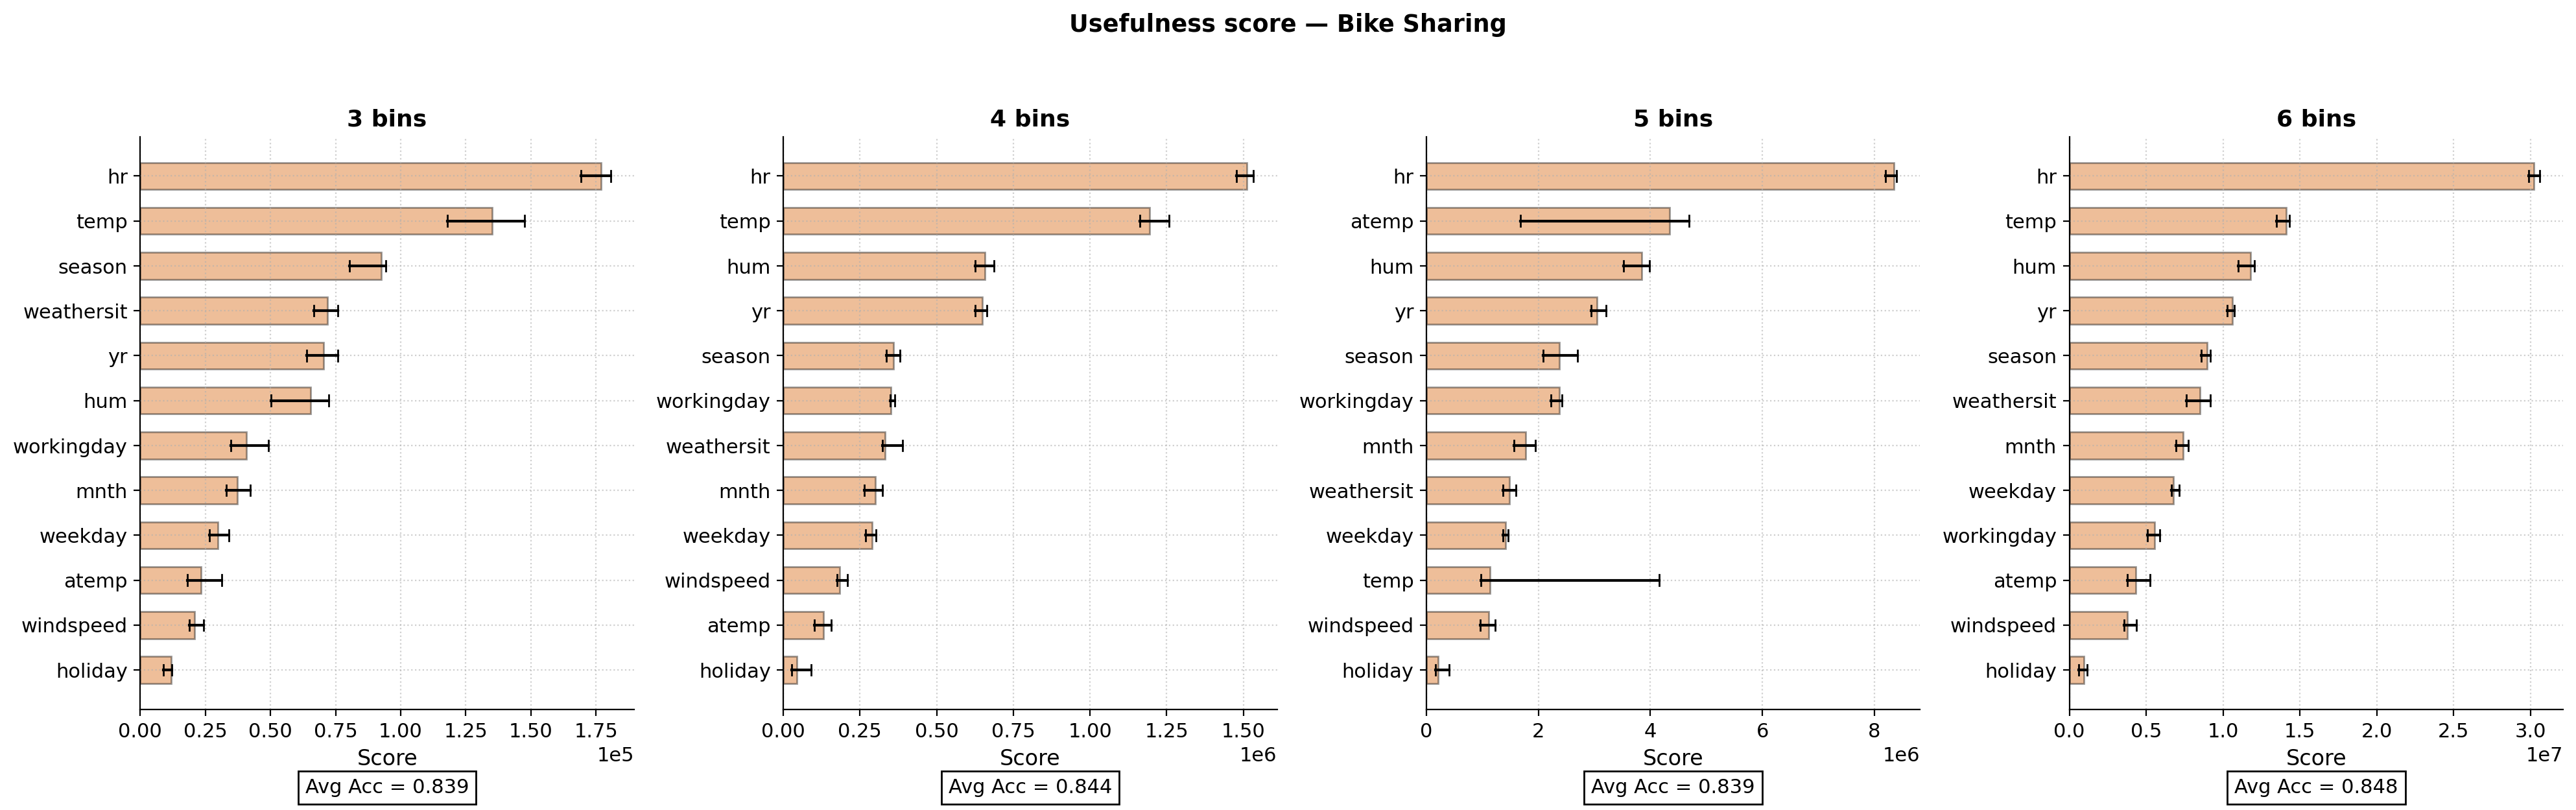

,dataset,strategy,bins,feature,q1,median,q3,mean_accuracy
0,bike_sharing,uniform,3,holiday,8947.00,11781.0,12048.50,0.838751
1,bike_sharing,uniform,3,windspeed,18738.75,20937.0,24371.25,0.838751
2,bike_sharing,uniform,3,atemp,18005.25,23424.0,31189.50,0.838751
3,bike_sharing,uniform,3,weekday,26643.75,29821.5,34045.50,0.838751
4,bike_sharing,uniform,3,mnth,33101.25,37207.5,42357.00,0.838751
5,bike_sharing,uniform,3,workingday,34690.50,40721.0,49136.50,0.838751
6,bike_sharing,uniform,3,hum,50086.50,65392.5,72382.50,0.838751
7,bike_sharing,uniform,3,yr,63998.00,70356.0,75844.50,0.838751
8,bike_sharing,uniform,3,weathersit,66673.00,71764.0,75880.00,0.838751
9,bike_sharing,uniform,3,season,80318.00,92524.0,94385.00,0.838751


In [23]:
scores = ux.run_score_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scores(scores, DATASET, f'{TAG}_usefulness_scores')
show(f'{TAG}_usefulness_scores')
scores['table'].head(12)   # per-feature quartiles (tidy table, also saved to CSV)

## 2. Comparison with other importance methods

Compute every method on the **same** trees and compare the *rankings* they induce:
a normalized-importance heatmap, pairwise rank correlation, and top-k overlap with
the usefulness ranking.

In [ ]:
comp = ux.run_comparison_experiment(DATASET, cfg, bins=6, methods=METHODS, n_models=N_MODELS)
for _name, _fn in [('importance_heatmap',      ux.plot_method_importance_heatmap),
                   ('rank_correlation',        ux.plot_rank_correlation_heatmap),
                   ('topk_overlap',            ux.plot_topk_intersection)]:
    _fn(comp, f'{TAG}_{_name}')
    show(f'{TAG}_{_name}')
print('Mean Spearman rank correlation with usefulness:')
display(comp['corr_spearman']['usefulness'].drop('usefulness').sort_values(ascending=False).round(3))

## 3. Runtime analysis

How the usefulness algorithm scales with the number of bins and the tree size
(via `perf_counter`; the tree-size panel overlays a power-law fit to show
empirical complexity), and the wall-clock cost of every importance method on
the same model.

In [ ]:
scaling = ux.scaling_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scaling(scaling, DATASET, f'{TAG}_scaling')
show(f'{TAG}_scaling')

_leaves = cfg.leaves_per_bin[DATASET] * 6
model = ux.train_tree(DATASET, bins=6, strategy='uniform', seed=42, leaves=_leaves)
runtimes = ux.method_runtime_comparison(model, cfg, methods=METHODS)
ux.plot_method_runtimes(runtimes, DATASET, f'{TAG}_method_runtimes')
show(f'{TAG}_method_runtimes')
runtimes

### A fairer performance picture

The raw runtime bar is a bit unfair to the usefulness score: the prototype spent
most of its time in `copy.deepcopy`, not the algorithm — a copy-free scorer is
~5x faster with *identical* results.

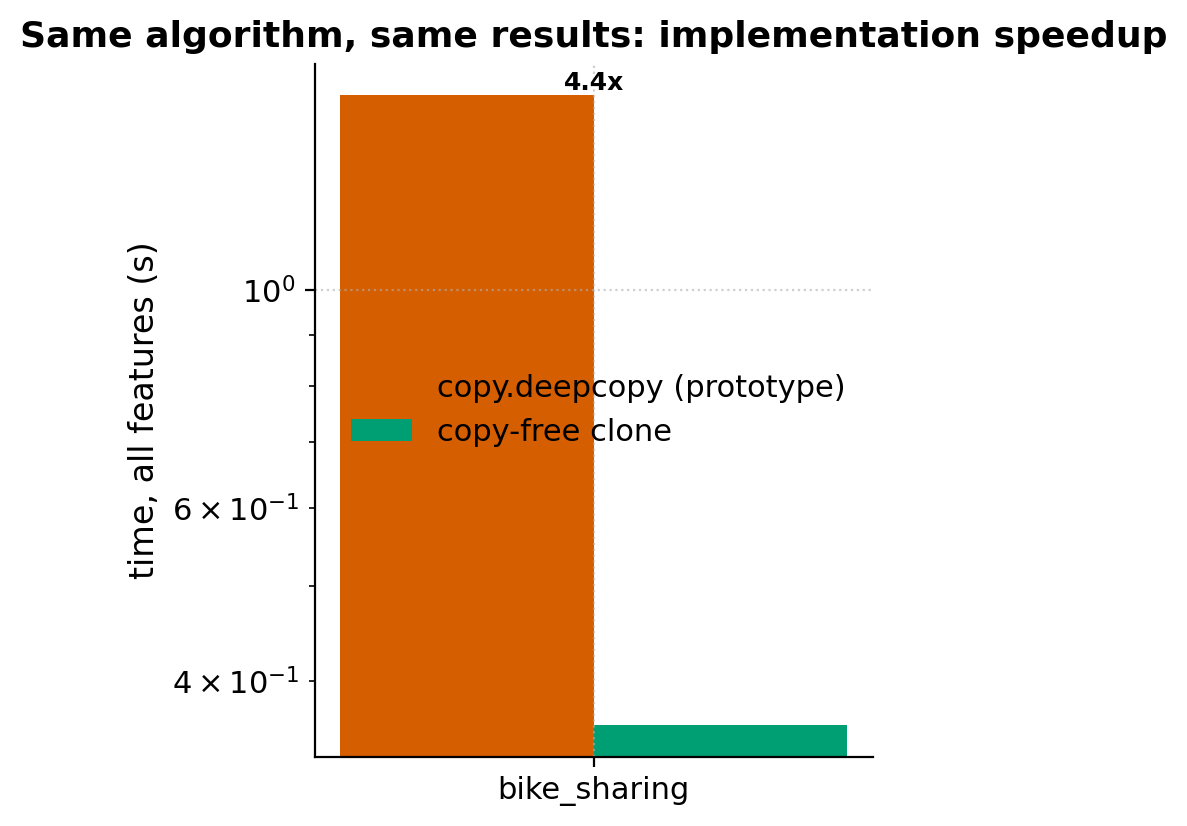

 deepcopy_s  clone_s  speedup
      1.581    0.361     4.38


In [28]:
import pandas as pd
# (a) implementation speedup (same algorithm, identical results)
speedup = pd.DataFrame([ux.profile_scorer_speedup(model)])
ux.plot_scorer_speedup(speedup, f'{TAG}_scorer_speedup'); show(f'{TAG}_scorer_speedup')
print(speedup[['deepcopy_s', 'clone_s', 'speedup']].round(3).to_string(index=False))

## 4. Binning-strategy sensitivity

Re-run under `uniform` / `quantile` / `kmeans` discretisation and measure accuracy
and how much the induced ranking moves between strategies.

In [ ]:
binning = ux.run_binning_experiment(DATASET, cfg, n_models=N_MODELS)
ux.plot_binning_sensitivity(binning, DATASET, f'{TAG}_binning')
show(f'{TAG}_binning')
binning['summary'].round(3)

## Reproduce all three datasets

Set `DATASET` to `california` or `adult_income` above and *Run All*, or run everything
headless with the driver (identical results, no notebook state to worry about):

```bash
python experiments_driver.py --datasets california bike_sharing adult_income --n-models 20
```